In [1]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
from collections import Counter

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams['font.size'] = 8

In [2]:
sim_name = '_cancel'
h_scales1 = np.linspace(-1,1,11)
h_scales2 = np.linspace(0,1,11)
rounds = 2
errs_by_wt = {}
pt_errs_by_wt = {}
pt_pt_errs_by_wt = {}
err_per_q = {}
pt_err_per_q = {}
pt_pt_err_per_q = {}
for h1 in h_scales1:
    for h2 in h_scales2:
        try:
            with open(f'data/bb_code_simulation_{h1}_{h2}_{rounds}{sim_name}.pkl', 'rb') as f:
                results_dict = pickle.load(f)
            f.close()
            
            errors = np.logical_xor(results_dict['obs'], results_dict['samples'][1])
            pt_errors = np.logical_xor(results_dict['pt_obs'], results_dict['samples'][1])
            pt_pt_errors = np.logical_xor(results_dict['pt_pt_obs'], results_dict['pt_samples'][1])
    
            wts = Counter(np.sum(errors, axis=1))
            pt_wts = Counter(np.sum(pt_errors, axis=1))
            pt_pt_wts = Counter(np.sum(pt_pt_errors, axis=1))

            shots = len(results_dict['samples'][1])*12
    
            errs_by_wt[(h1,h2)] = wts
            pt_errs_by_wt[(h1,h2)] = pt_wts
            pt_pt_errs_by_wt[(h1,h2)] = pt_pt_wts
            err_per_q[(h1,h2)] = np.sum(results_dict['obs'] != results_dict['samples'][1])/shots
            pt_err_per_q[(h1,h2)] = np.sum(results_dict['pt_obs'] != results_dict['samples'][1])/shots
            pt_pt_err_per_q[(h1,h2)] = np.sum(results_dict['pt_pt_obs'] != results_dict['pt_samples'][1])/shots
    
            #print(h1, h2, np.sum(results_dict['obs'] != results_dict['samples'][1])/shots, np.sum(results_dict['pt_obs'] != results_dict['samples'][1])/shots, np.sum(results_dict['pt_pt_obs'] != results_dict['pt_samples'][1])/shots) #results_dict['dem'])
        except:
            pass


-1.0 0.0 0.004119166666666667 0.0042225 0.0037816666666666667
-1.0 0.1 0.0033991666666666667 0.0032533333333333333 0.0038675
-1.0 0.2 0.0032333333333333333 0.003319166666666667 0.00363
-1.0 0.30000000000000004 0.003320833333333333 0.003315 0.004158333333333333
-1.0 0.4 0.0034016666666666666 0.0033066666666666665 0.004120833333333333
-1.0 0.5 0.0037916666666666667 0.0038683333333333334 0.004020833333333334
-1.0 0.6000000000000001 0.004055 0.0041375 0.004626666666666667
-1.0 0.7000000000000001 0.004714166666666667 0.0046 0.0047075
-1.0 0.8 0.005555 0.0055375 0.005233333333333334
-1.0 0.9 0.00731 0.0073225 0.005433333333333333
-1.0 1.0 0.008815833333333334 0.0092075 0.005726666666666666
-0.8 0.0 0.0026383333333333332 0.0025991666666666667 0.002415833333333333
-0.8 0.1 0.0023875 0.00235 0.002544166666666667
-0.8 0.2 0.0022083333333333334 0.0022175 0.002585833333333333
-0.8 0.30000000000000004 0.002155 0.0022208333333333333 0.0028033333333333335
-0.8 0.4 0.0022733333333333334 0.0023325 0.00

{-0.03162277660168379, 0.0, 0.03162277660168379, 0.012649110640673521, 0.025298221281347035, -0.025298221281347035, -0.012649110640673514, 0.01897366596101028, -0.006324555320336757, -0.018973665961010275, 0.006324555320336764}


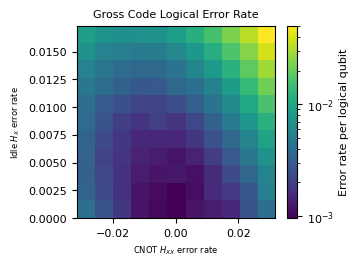

In [60]:
def create_heatmap(data_dict, x_bins=11, y_bins=11, filepath=None, log=True):
    plt.figure(figsize=(3.2,2.5))
    # Extract x and y coordinates and values from the dictionary
    x_coords = [key[0]*np.sqrt(0.001) for key in data_dict.keys()]
    y_coords = [key[1]*np.sqrt(0.0003) for key in data_dict.keys()]
    print(set(x_coords))
    values = list(data_dict.values())

    # Create a grid for the heatmap
    heatmap, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=[x_bins, y_bins], weights=values)

    # Create the extent for the heatmap
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

    # Plotting the heatmap with logarithmic normalization
    #plt.figure(figsize=(10, 8))
    if log:
        im = plt.imshow(heatmap.T, extent=extent, origin='lower', aspect='auto', 
                    cmap='viridis', norm=LogNorm(vmin=None, vmax=heatmap.max()))
    else:
        im = plt.imshow(heatmap.T, extent=extent, origin='lower', aspect='auto', 
                    cmap='viridis')
    cbar = plt.colorbar(im, label='Error rate per logical qubit')
    plt.xlabel(r'''CNOT $H_{XX}$ error rate''',fontsize=6)
    plt.ylabel(r'''Idle $H_{X}$ error rate''',fontsize=6)
    plt.title(f'Gross Code Logical Error Rate',fontsize=8)
    if filepath is None:
        plt.show()
    else:
        plt.savefig(filepath)

create_heatmap(err_per_q, filepath=None) #f'plots/gross_two_param_sweep{sim_name}_{rounds}.pdf'

In [88]:
#data_dict

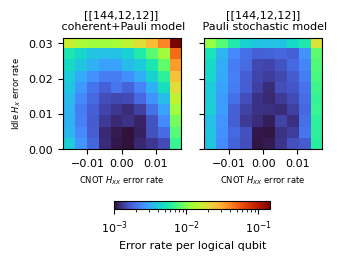

In [99]:
def create_side_by_side_heatmaps(data_dict1, data_dict2, x_bins=10, y_bins=10, filepath=None):
    # Create a figure with two subplots
    fig, axs = plt.subplots(1, 2, figsize=(3.35, 2.5), sharey=True)
    
    # Extract x and y coordinates and values from the first dictionary
    x_coords1 = [key[0]*np.sqrt(0.0003)  for key in list(data_dict1.keys())]
    y_coords1 = [key[1]*np.sqrt(0.001)  for key in list(data_dict1.keys())]
    values1 = list(data_dict1.values())

    # Create a grid for the first heatmap
    heatmap1, xedges1, yedges1 = np.histogram2d(x_coords1, y_coords1, bins=[x_bins, y_bins], weights=values1)

    # Create the extent for the first heatmap
    extent1 = [xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]]

    # Plotting the first heatmap
    im1 = axs[0].imshow(heatmap1.T, extent=extent1, origin='lower', aspect='auto', 
                        cmap='turbo', norm=LogNorm(vmin=1e-3, vmax=max(heatmap1.max(), 1e-3)))  # Adjust vmin as needed
    axs[0].set_xlabel(r'''CNOT $H_{XX}$ error rate''', fontsize=6)
    axs[0].set_ylabel(r'''Idle $H_{X}$ error rate''', fontsize=6)  
    axs[0].set_title('[[144,12,12]]\n coherent+Pauli model', fontsize=8)

    # Extract x and y coordinates and values from the second dictionary
    x_coords2 = [key[0]*np.sqrt(0.0003) for key in list(data_dict2.keys())]
    y_coords2 = [key[1]*np.sqrt(0.001) for key in list(data_dict2.keys())]
    values2 = list(data_dict2.values())

    # Create a grid for the second heatmap
    heatmap2, xedges2, yedges2 = np.histogram2d(x_coords2, y_coords2, bins=[x_bins, y_bins], weights=values2)

    # Create the extent for the second heatmap
    extent2 = [xedges2[0], xedges2[-1], yedges2[0], yedges2[-1]]

    # Plotting the second heatmap
    im2 = axs[1].imshow(heatmap2.T, extent=extent2, origin='lower', aspect='auto', 
                        cmap='turbo',norm=im1.norm)  # Use the same color scale as the first heatmap #
    axs[1].set_xlabel(r'''CNOT $H_{XX}$ error rate''', fontsize=6)
    axs[1].set_title('[[144,12,12]]\n Pauli stochastic model', fontsize=8)

    # Add a colorbar to the figure below the plots
    cbar = fig.colorbar(im1, ax=axs, orientation='horizontal', pad=0.27, shrink=0.6)
    cbar.set_label('Error rate per logical qubit')

    # Adjust layout
    #plt.tight_layout()

    if filepath is None:
        plt.show()
    else:
        plt.savefig(filepath)

# Example usage
create_side_by_side_heatmaps(err_per_q,pt_pt_err_per_q,filepath=f'plots/gross_two_param{sim_name}_{rounds}_compare.pdf') #{k:v for k,v in err_per_q.items() if np.abs(k[0])<0.8 and k[1]<0.8}, {k:v for k,v in pt_pt_err_per_q.items() if np.abs(k[0])<0.8 and k[1]<0.8}, x_bins=7, y_bins=7, filepath=None)#f'plots/gross_two_param{sim_name}_{rounds}_compare.pdf')

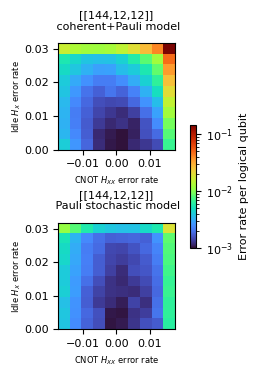

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def create_side_by_side_heatmaps(data_dict1, data_dict2, x_bins=10, y_bins=10, filepath=None):
    # Create a figure with two subplots
    fig, axs = plt.subplots(2, 1, figsize=(2, 4), sharey=True)  # Adjusted width for better square aspect ratio
    
    # Extract x and y coordinates and values from the first dictionary
    x_coords1 = [key[0]*np.sqrt(0.0003) for key in list(data_dict1.keys())]
    y_coords1 = [key[1]*np.sqrt(0.001) for key in list(data_dict1.keys())]
    values1 = list(data_dict1.values())

    # Create a grid for the first heatmap
    heatmap1, xedges1, yedges1 = np.histogram2d(x_coords1, y_coords1, bins=[x_bins, y_bins], weights=values1)

    # Create the extent for the first heatmap
    extent1 = [xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]]

    # Plotting the first heatmap with equal aspect ratio
    im1 = axs[0].imshow(heatmap1.T, extent=extent1, origin='lower', aspect='equal', 
                        cmap='turbo', norm=LogNorm(vmin=1e-3, vmax=max(heatmap1.max(), 1e-3)))  # Adjust vmin as needed
    axs[0].set_xlabel(r'''CNOT $H_{XX}$ error rate''', fontsize=6)
    axs[0].set_ylabel(r'''Idle $H_{X}$ error rate''', fontsize=6, labelpad=1)  
    axs[0].set_title('[[144,12,12]]\n coherent+Pauli model', fontsize=8, pad=10)

    # Extract x and y coordinates and values from the second dictionary
    x_coords2 = [key[0]*np.sqrt(0.0003) for key in list(data_dict2.keys())]
    y_coords2 = [key[1]*np.sqrt(0.001) for key in list(data_dict2.keys())]
    values2 = list(data_dict2.values())

    # Create a grid for the second heatmap
    heatmap2, xedges2, yedges2 = np.histogram2d(x_coords2, y_coords2, bins=[x_bins, y_bins], weights=values2)

    # Create the extent for the second heatmap
    extent2 = [xedges2[0], xedges2[-1], yedges2[0], yedges2[-1]]

    # Plotting the second heatmap with equal aspect ratio
    im2 = axs[1].imshow(heatmap2.T, extent=extent2, origin='lower', aspect='equal', 
                        cmap='turbo', norm=im1.norm)  # Use the same color scale as the first heatmap
    axs[1].set_xlabel(r'''CNOT $H_{XX}$ error rate''', fontsize=6)
    axs[1].set_ylabel(r'''Idle $H_{X}$ error rate''', fontsize=6, labelpad=1) 
    axs[1].set_title('[[144,12,12]]\n Pauli stochastic model', fontsize=8, pad=10)

    # Add a colorbar to the figure below the plots


    # Adjust layout to prevent overlap
    plt.subplots_adjust(hspace=0.4)  # Adjust space between subplots

    if filepath is None:
        plt.show()
    else:
        plt.savefig(filepath)

    cbar = fig.colorbar(im1, ax=axs, orientation='vertical', pad=0.1, shrink=0.4)
    cbar.set_label('Error rate per logical qubit')

# Example usage
create_side_by_side_heatmaps(err_per_q, pt_pt_err_per_q, filepath=f'plots/gross_two_param{sim_name}_{rounds}_compare_v2.pdf')

{-0.03162277660168379, 0.0, 0.03162277660168379, 0.012649110640673521, 0.025298221281347035, -0.025298221281347035, -0.012649110640673514, 0.01897366596101028, -0.006324555320336757, -0.018973665961010275, 0.006324555320336764}


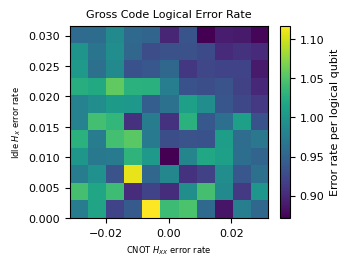

In [90]:
create_heatmap({v:err_per_q[v]/pt_err_per_q[v] for v in err_per_q}, filepath=f'plots/gross_two_param_sweep_pt{sim_name}_{rounds}.pdf', log=False)

{-0.03162277660168379, 0.0, 0.03162277660168379, 0.012649110640673521, 0.025298221281347035, -0.025298221281347035, -0.012649110640673514, 0.01897366596101028, -0.006324555320336757, -0.018973665961010275, 0.006324555320336764}


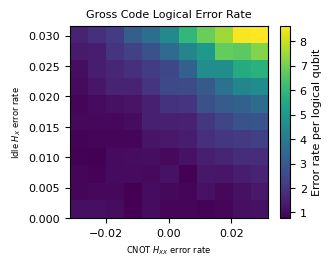

In [109]:
create_heatmap({v:err_per_q[v]/pt_pt_err_per_q[v] for v in err_per_q}, filepath=f'plots/gross_two_param_sweep_pt_compare{sim_name}_{rounds}.pdf', log=False)

{-0.03162277660168379, 0.0, 0.03162277660168379, 0.012649110640673521, 0.025298221281347035, -0.025298221281347035, -0.012649110640673514, 0.01897366596101028, -0.006324555320336757, -0.018973665961010275, 0.006324555320336764}


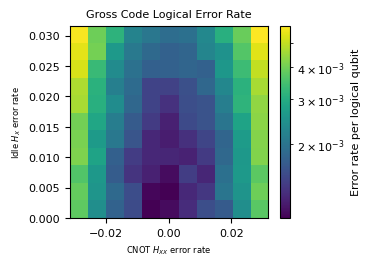

In [92]:
create_heatmap(pt_pt_err_per_q, filepath=f'plots/gross_two_param_sweep_pt{sim_name}_{rounds}.pdf')

In [ ]:
sim_name = '_cancel'
h_scales1 = np.linspace(-1,1,11)
h_scales2 = [0.4, 0.6000000000000001]
rounds = 2

for h1 in h_scales1:
    for h2 in h_scales2:
        with open(f'data/bb_code_simulation_{h1}_{h2}_{rounds}{sim_name}.pkl', 'rb') as f: #with open(f'data/bb_code_simulation_{h1}_{h2}_2_w_idle.pkl', 'rb') as f:
            results_dict = pickle.load(f)
        f.close()

        errs_dem = np.logical_xor(results_dict['obs'], results_dict['samples'][1])
        errs_pt = np.logical_xor(results_dict['pt_obs'], results_dict['samples'][1])
        errs_pt_pt = np.logical_xor(results_dict['pt_pt_obs'], results_dict['pt_samples'][1])
        
        for i in range(0,13):
            try:
                with open(f'data/bb_code_simulation_{h1}_{h2}_{rounds}_cancel_slice.pkl', 'rb') as f:
                    results_dict = pickle.load(f)
                f.close()
        
                errors = np.logical_xor(results_dict['obs'], results_dict['samples'][1])
                pt_errors = np.logical_xor(results_dict['pt_obs'], results_dict['samples'][1])
                pt_pt_errors = np.logical_xor(results_dict['pt_pt_obs'], results_dict['pt_samples'][1])
        
                wts = Counter(np.sum(errors, axis=1))
                pt_wts = Counter(np.sum(pt_errors, axis=1))
                pt_pt_wts = Counter(np.sum(pt_pt_errors, axis=1))
        
                errs_dem = np.append(errs_dem, errors)
                errs_pt = np.append(errs_pt, pt_errors)
                errs_pt_pt = np.append(errs_pt_pt, pt_pt_errors)
            
                        
                
                print(h1, h2, np.sum(results_dict['obs'] != results_dict['samples'][1])/shots, np.sum(results_dict['pt_obs'] != results_dict['samples'][1])/shots, np.sum(results_dict['pt_pt_obs'] != results_dict['pt_samples'][1])/shots) #results_dict['dem'])
            except:
                pass

        shots = np.size(errs_dem)

        err_per_q[(h1,h2)] = np.sum(errs_dem)/np.size(errs_dem)
        pt_err_per_q[(h1,h2)] = np.sum(errs_pt)/np.size(errs_pt)
        pt_pt_err_per_q[(h1,h2)] = np.sum(errs_pt_pt)/np.size(errs_pt_pt)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

upto = 11
p = 1
xs = [np.sqrt(0.001 * p) * h for h in h_scales1[:upto]]

plt.figure(figsize=(2.5, 2))

# Plotting for h2 = 0.6000000000000001
for h2 in [0.6000000000000001, 0.4]:
    # Scatter plot
    plt.scatter(xs, [err_per_q[(h1, h2)] for h1 in h_scales1[:upto]], label=rf'$h_{{I, X}}$={np.sqrt(0.0003) * h2}', alpha=1, marker='.')
    plt.scatter(xs, [pt_err_per_q[(h1, h2)] for h1 in h_scales1[:upto]], label=rf'$h_{{I, X}}$={np.sqrt(0.0003) * h2}, Pauli-informed decoder', alpha=1, marker='.')
    plt.scatter(xs, [pt_pt_err_per_q[(h1, h2)] for h1 in h_scales1[:upto]], label=rf'$h_{{I, X}}$={np.sqrt(0.0003) * h2}, Pauli-twirled model and decoder', alpha=1, marker='.')

    # Dashed line plot with alpha=0.5
    plt.plot(xs, [err_per_q[(h1, h2)] for h1 in h_scales1[:upto]], linestyle='--', alpha=0.5)
    plt.plot(xs, [pt_err_per_q[(h1, h2)] for h1 in h_scales1[:upto]], linestyle='--', alpha=0.5)
    plt.plot(xs, [pt_pt_err_per_q[(h1, h2)] for h1 in h_scales1[:upto]], linestyle='--', alpha=0.5)

plt.legend(loc=(1.02, 0),fontsize=6)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.yscale('log')
plt.ylim(1e-3, 2e-2)
plt.xlabel('CNOT $H_{XX}$ error',fontsize=8)
plt.ylabel('Logical error probability \nper qubit', fontsize=8)
plt.savefig(f'plots/ler_slice_{sim_name}.pdf')